In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/customer_churn_raw.csv")

# Basic overview
print("Dataset Shape:", df.shape)

display(df.head())

print("\nColumn Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (100500, 16)


,customer_id,age,gender,city,acquisition_channel,subscription_plan,payment_method,signup_date,tenure_months,orders_count,monthly_spend,discount_usage_rate,support_tickets,satisfaction_score,last_order_date,churn
0,178303,23.0,Male,Ahmedabad,Referral,Standard,Wallet,12-10-2023,27,7,14545.09,0.666,1,5,21-09-2025,0
1,166465,48.0,Male,Mumbai,Social Media,Premium,Debit Card,14-12-2023,24,2,4134.45,0.173,3,4,29-11-2025,0
2,193228,31.0,Female,Delhi,Paid Ads,Basic,Debit Card,25-02-2024,22,1,776.62,0.499,0,5,21-05-2025,0
3,101748,46.0,Female,Pune,Social Media,Basic,Wallet,18-07-2024,17,1,1001.58,0.437,1,4,23-12-2025,1
4,180005,37.0,Female,Bangalore,Organic,Basic,Debit Card,16-11-2023,25,2,2383.86,0.629,5,2,20-09-2025,1



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100500 non-null  int64  
 1   age                  98991 non-null   float64
 2   gender               99497 non-null   object 
 3   city                 99494 non-null   object 
 4   acquisition_channel  100500 non-null  object 
 5   subscription_plan    100500 non-null  object 
 6   payment_method       100500 non-null  object 
 7   signup_date          100500 non-null  object 
 8   tenure_months        100500 non-null  int64  
 9   orders_count         100500 non-null  int64  
 10  monthly_spend        99696 non-null   float64
 11  discount_usage_rate  100500 non-null  float64
 12  support_tickets      100500 non-null  int64  
 13  satisfaction_score   100500 non-null  int64  
 14  last_order_date      100500 non-null  object 
 

customer_id               0
age                    1509
gender                 1003
city                   1006
acquisition_channel       0
subscription_plan         0
payment_method            0
signup_date               0
tenure_months             0
orders_count              0
monthly_spend           804
discount_usage_rate       0
support_tickets           0
satisfaction_score        0
last_order_date           0
churn                     0
dtype: int64


Duplicate Rows: 500


In [31]:
# Data Quality & Cleaning

# 1. Check duplicate customer IDs
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

# 2. Remove exact duplicate rows
duplicate_rows = df.duplicated().sum()
df = df.drop_duplicates().copy()

print("Exact duplicate rows removed:", duplicate_rows)
print("Shape after removing duplicates:", df.shape)

# 3. Handle missing numerical values
df["age"] = df["age"].fillna(df["age"].median())
df["monthly_spend"] = df["monthly_spend"].fillna(df["monthly_spend"].median())

# 4. Handle missing categorical values
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["city"] = df["city"].fillna("Unknown")

# 5. Convert date columns to datetime
df["signup_date"] = pd.to_datetime(df["signup_date"], dayfirst=True)
df["last_order_date"] = pd.to_datetime(df["last_order_date"], dayfirst=True)

# 6. Basic validity checks
print("\nMissing values after cleaning:")
display(df.isnull().sum())

print("\nData types after cleaning:")
display(df.dtypes)

print("\nBasic numeric validity:")
print("Age range:", df["age"].min(), "to", df["age"].max())
print("Monthly spend range:", df["monthly_spend"].min(), "to", df["monthly_spend"].max())
print("Tenure range:", df["tenure_months"].min(), "to", df["tenure_months"].max())
print("Orders range:", df["orders_count"].min(), "to", df["orders_count"].max())
print("Churn values:", sorted(df["churn"].unique()))

Duplicate customer IDs: 500
Exact duplicate rows removed: 500
Shape after removing duplicates: (100000, 16)

Missing values after cleaning:


customer_id            0
age                    0
gender                 0
city                   0
acquisition_channel    0
subscription_plan      0
payment_method         0
signup_date            0
tenure_months          0
orders_count           0
monthly_spend          0
discount_usage_rate    0
support_tickets        0
satisfaction_score     0
last_order_date        0
churn                  0
dtype: int64


Data types after cleaning:


customer_id                     int64
age                           float64
gender                         object
city                           object
acquisition_channel            object
subscription_plan              object
payment_method                 object
signup_date            datetime64[ns]
tenure_months                   int64
orders_count                    int64
monthly_spend                 float64
discount_usage_rate           float64
support_tickets                 int64
satisfaction_score              int64
last_order_date        datetime64[ns]
churn                           int64
dtype: object


Basic numeric validity:
Age range: 18.0 to 130.0
Monthly spend range: 200.0 to 999999.0
Tenure range: 1 to 60
Orders range: -1 to 17
Churn values: [np.int64(0), np.int64(1)]


In [32]:
# Data Validation & Outlier Investigation

# Define expected logical ranges
validation_checks = {
    "age < 18": (df["age"] < 18).sum(),
    "age > 100": (df["age"] > 100).sum(),
    "negative orders": (df["orders_count"] < 0).sum(),
    "negative monthly spend": (df["monthly_spend"] < 0).sum(),
    "negative tenure": (df["tenure_months"] < 0).sum(),
    "invalid satisfaction score": (
        (df["satisfaction_score"] < 1) | 
        (df["satisfaction_score"] > 5)
    ).sum(),
    "invalid discount rate": (
        (df["discount_usage_rate"] < 0) | 
        (df["discount_usage_rate"] > 1)
    ).sum()
}

print("Potential invalid values:")
for check, count in validation_checks.items():
    print(f"{check}: {count}")

# Summary statistics for numerical variables
numeric_cols = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score"
]

print("\nNumerical summary:")
display(df[numeric_cols].describe().T)

# Fix Clearly Invalid Values

# Replace impossible ages (>100) with median age
invalid_age_count = (df["age"] > 100).sum()
df.loc[df["age"] > 100, "age"] = df["age"].median()

# Replace negative order counts with median orders
invalid_orders_count = (df["orders_count"] < 0).sum()
df.loc[df["orders_count"] < 0, "orders_count"] = df["orders_count"].median()

print(f"Invalid age values replaced: {invalid_age_count}")
print(f"Invalid order count values replaced: {invalid_orders_count}")

# Verify
print("\nUpdated ranges:")
print("Age:", df["age"].min(), "to", df["age"].max())
print("Orders:", df["orders_count"].min(), "to", df["orders_count"].max())

Potential invalid values:
age < 18: 0
age > 100: 5
negative orders: 5
negative monthly spend: 0
negative tenure: 0
invalid satisfaction score: 0
invalid discount rate: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
age,100000.0,42.096830,12.515726,18.000,33.0000,42.000,51.0000,130.000
tenure_months,100000.0,26.810960,13.996340,1.000,16.0000,24.000,35.0000,60.000
orders_count,100000.0,3.118630,1.997983,-1.000,2.0000,3.000,4.0000,17.000
monthly_spend,100000.0,4274.095493,8505.045267,200.000,1372.7475,2673.215,5153.0625,999999.000
discount_usage_rate,100000.0,0.530949,0.201264,0.003,0.3890,0.546,0.6840,0.989
support_tickets,100000.0,1.262510,1.243300,0.000,0.0000,1.000,2.0000,11.000
satisfaction_score,100000.0,4.266650,0.774515,1.000,4.0000,4.000,5.0000,5.000


Invalid age values replaced: 5
Invalid order count values replaced: 5

Updated ranges:
Age: 18.0 to 75.0
Orders: 1 to 17


Skewness of numerical features:


,skewness
monthly_spend,80.781373
support_tickets,1.249703
orders_count,1.151490
tenure_months,0.640833
age,0.137029
discount_usage_rate,-0.260760
satisfaction_score,-1.037616



IQR-based outlier summary:


,feature,Q1,Q3,lower_bound,upper_bound,outlier_count,outlier_%
0,age,33.0000,51.0000,6.0000,78.0000,0,0.00
1,tenure_months,16.0000,35.0000,-12.5000,63.5000,0,0.00
2,orders_count,2.0000,4.0000,-1.0000,7.0000,3540,3.54
3,monthly_spend,1372.7475,5153.0625,-4297.7250,10823.5350,7568,7.57
4,discount_usage_rate,0.3890,0.6840,-0.0535,1.1265,0,0.00
5,support_tickets,0.0000,2.0000,-3.0000,5.0000,701,0.70
6,satisfaction_score,4.0000,5.0000,2.5000,6.5000,2560,2.56


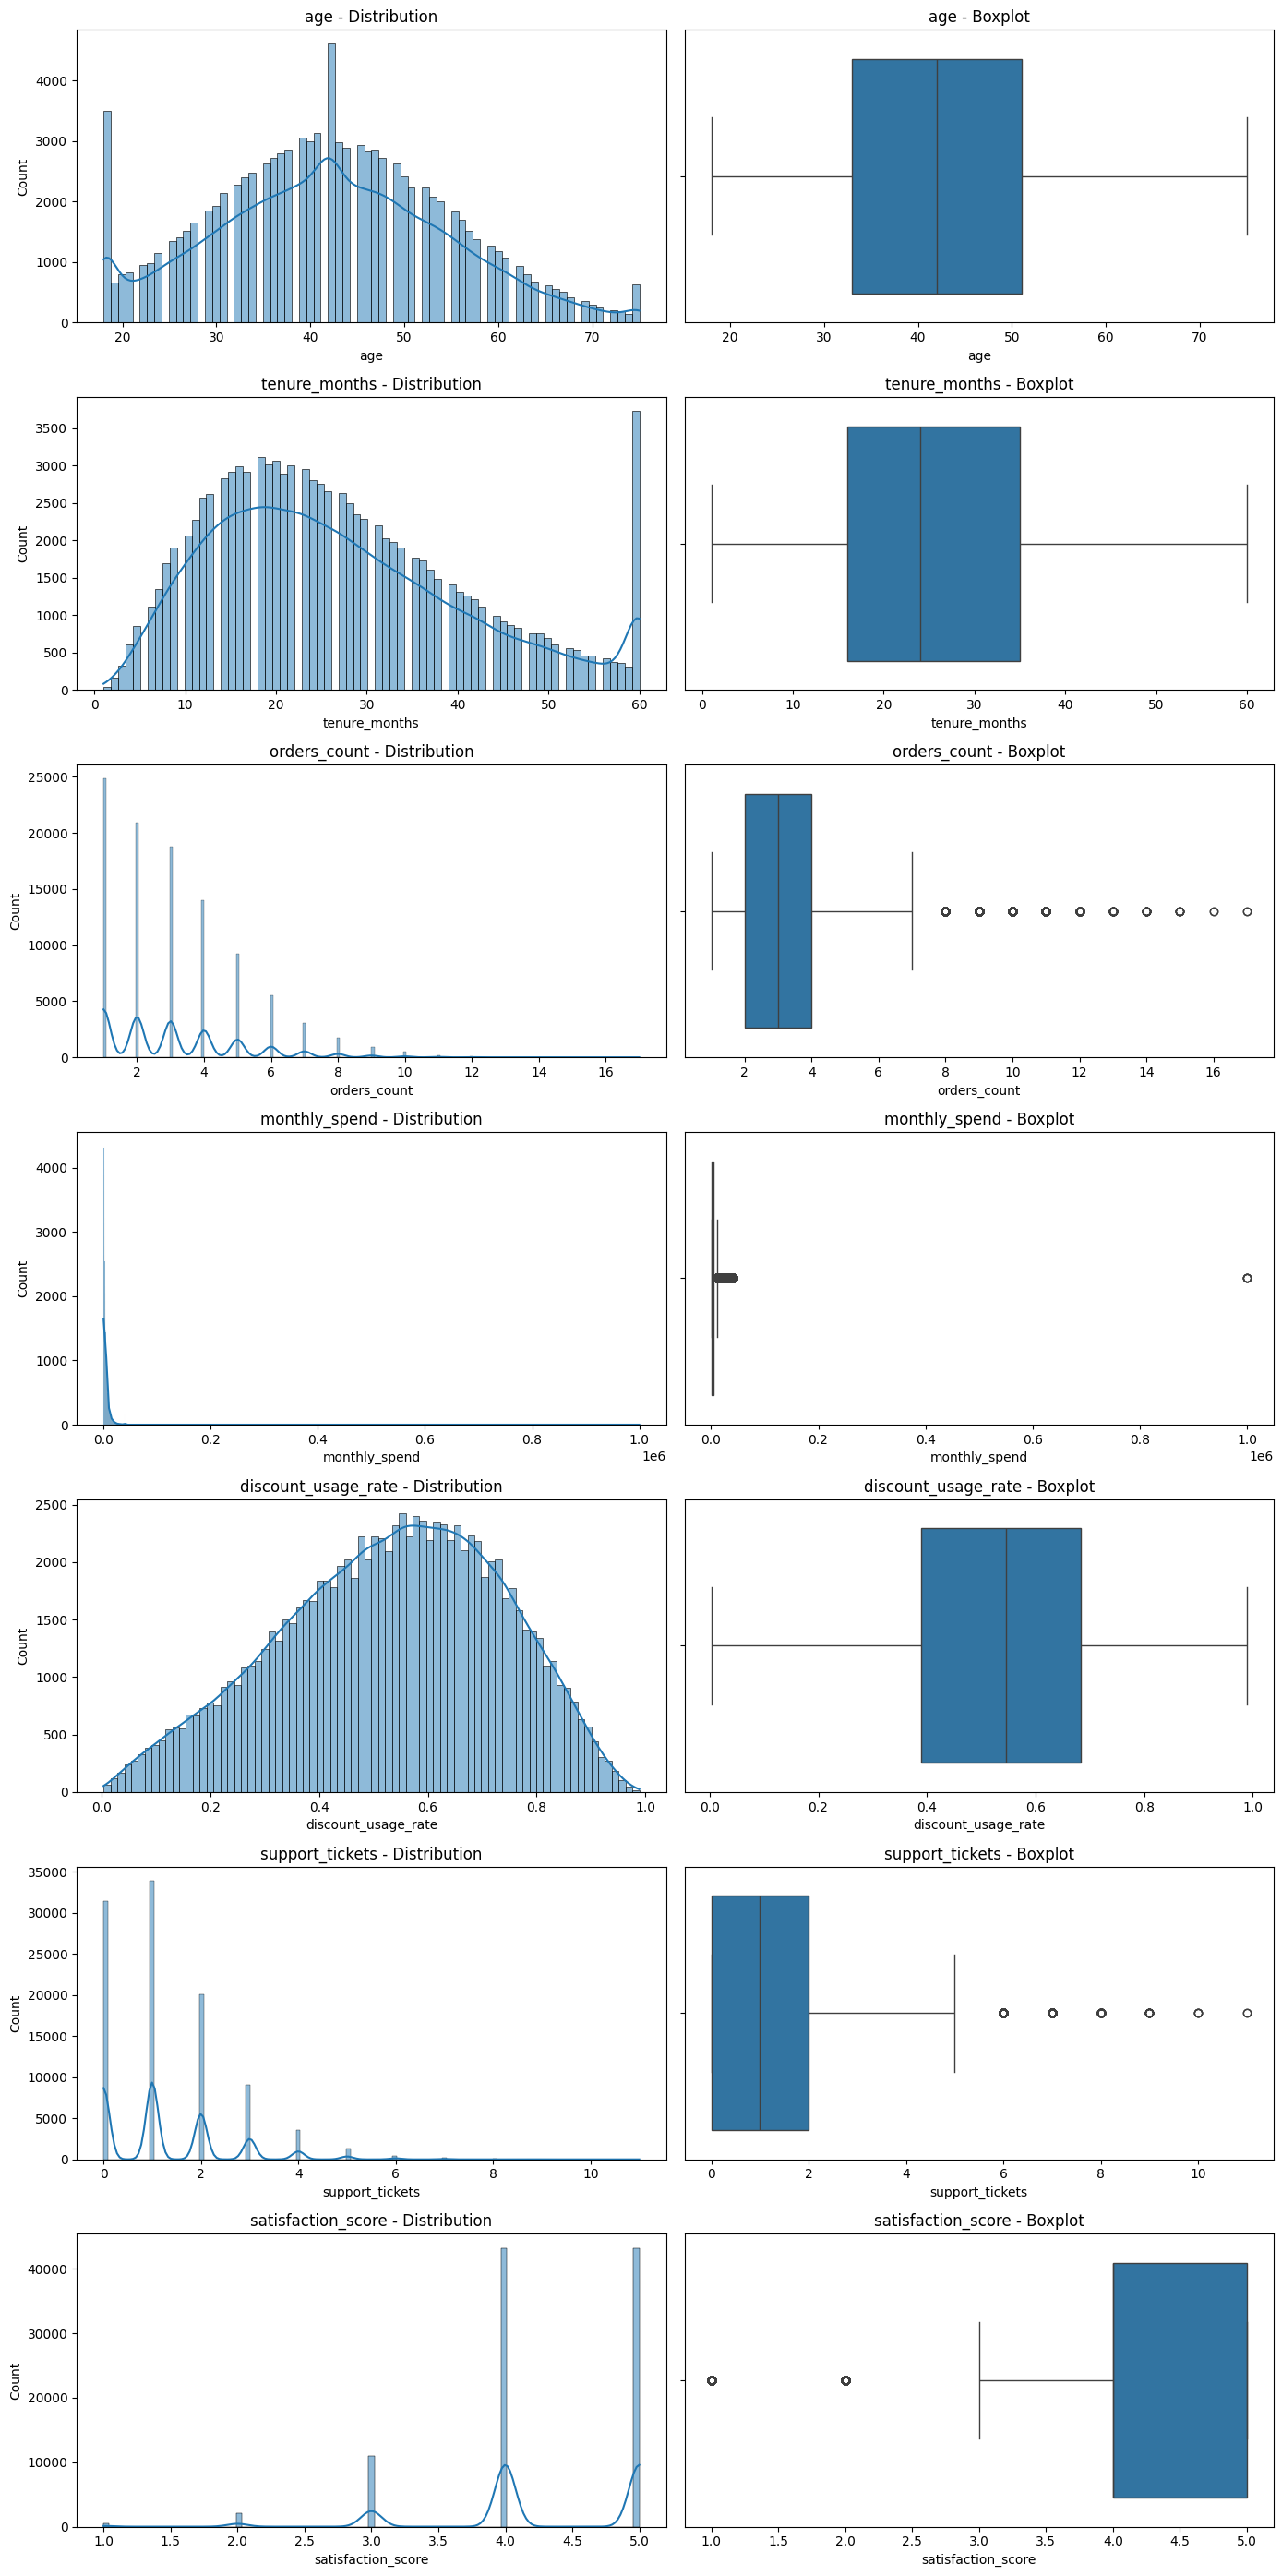

In [33]:

# Distribution, Skewness & Outlier Analysis
numeric_cols = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score"
]

# 1. Skewness
skewness = df[numeric_cols].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
display(skewness.to_frame("skewness"))

# 2. IQR-based outlier counts
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_%": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("\nIQR-based outlier summary:")
display(outlier_summary)

# 3. Distribution plots
fig, axes = plt.subplots(
    nrows=len(numeric_cols),
    ncols=2,
    figsize=(14, 4 * len(numeric_cols))
)

for i, col in enumerate(numeric_cols):

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Distribution")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()

In [34]:

# Investigate Monthly Spend Outliers

print("Highest monthly spend values:")
display(
    df["monthly_spend"]
    .sort_values(ascending=False)
    .head(20)
    .to_frame()
)

# Percentiles
percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]

print("\nMonthly spend percentiles:")
display(
    df["monthly_spend"]
    .quantile(percentiles)
    .to_frame("monthly_spend")
)

# Count extreme values
thresholds = [10000, 20000, 50000, 100000, 500000, 900000]

print("\nCustomers above spending thresholds:")

for threshold in thresholds:
    count = (df["monthly_spend"] > threshold).sum()
    percentage = count / len(df) * 100
    print(f"> ₹{threshold:,}: {count:,} customers ({percentage:.3f}%)")

# Check exact 999999 values
print("\nCustomers with monthly_spend = 999999:")
print((df["monthly_spend"] == 999999).sum())

# Handle Identified Spending Anomaly

# Identify clearly anomalous monthly spend values
anomalous_spend = df["monthly_spend"] == 999999

print("Anomalous monthly spend records:", anomalous_spend.sum())

# Replace anomalous values with median monthly spend
median_spend = df.loc[~anomalous_spend, "monthly_spend"].median()

df.loc[anomalous_spend, "monthly_spend"] = median_spend

print("Replacement value:", median_spend)

# Verify
print("\nUpdated monthly spend statistics:")
display(df["monthly_spend"].describe())

print(
    "\nRemaining 999999 values:",
    (df["monthly_spend"] == 999999).sum()
)

print(
    "New maximum monthly spend:",
    df["monthly_spend"].max()
)

Highest monthly spend values:


,monthly_spend
54892,999999.0
67319,999999.0
78590,999999.0
78940,999999.0
91018,999999.0
80849,40000.0
5677,40000.0
5664,40000.0
58023,40000.0
37634,40000.0



Monthly spend percentiles:


,monthly_spend
0.900,9358.7350
0.950,13297.1830
0.990,24327.8307
0.995,30451.0489
0.999,40000.0000



Customers above spending thresholds:
> ₹10,000: 8,774 customers (8.774%)
> ₹20,000: 1,833 customers (1.833%)
> ₹50,000: 5 customers (0.005%)
> ₹100,000: 5 customers (0.005%)
> ₹500,000: 5 customers (0.005%)
> ₹900,000: 5 customers (0.005%)

Customers with monthly_spend = 999999:
5
Anomalous monthly spend records: 5
Replacement value: 2673.215

Updated monthly spend statistics:


count    100000.000000
mean       4224.229204
std        4770.695593
min         200.000000
25%        1372.747500
50%        2673.215000
75%        5152.382500
max       40000.000000
Name: monthly_spend, dtype: float64


Remaining 999999 values: 0
New maximum monthly spend: 40000.0


Churn Distribution:


,count,percentage
churn,,
0,72840,72.84
1,27160,27.16


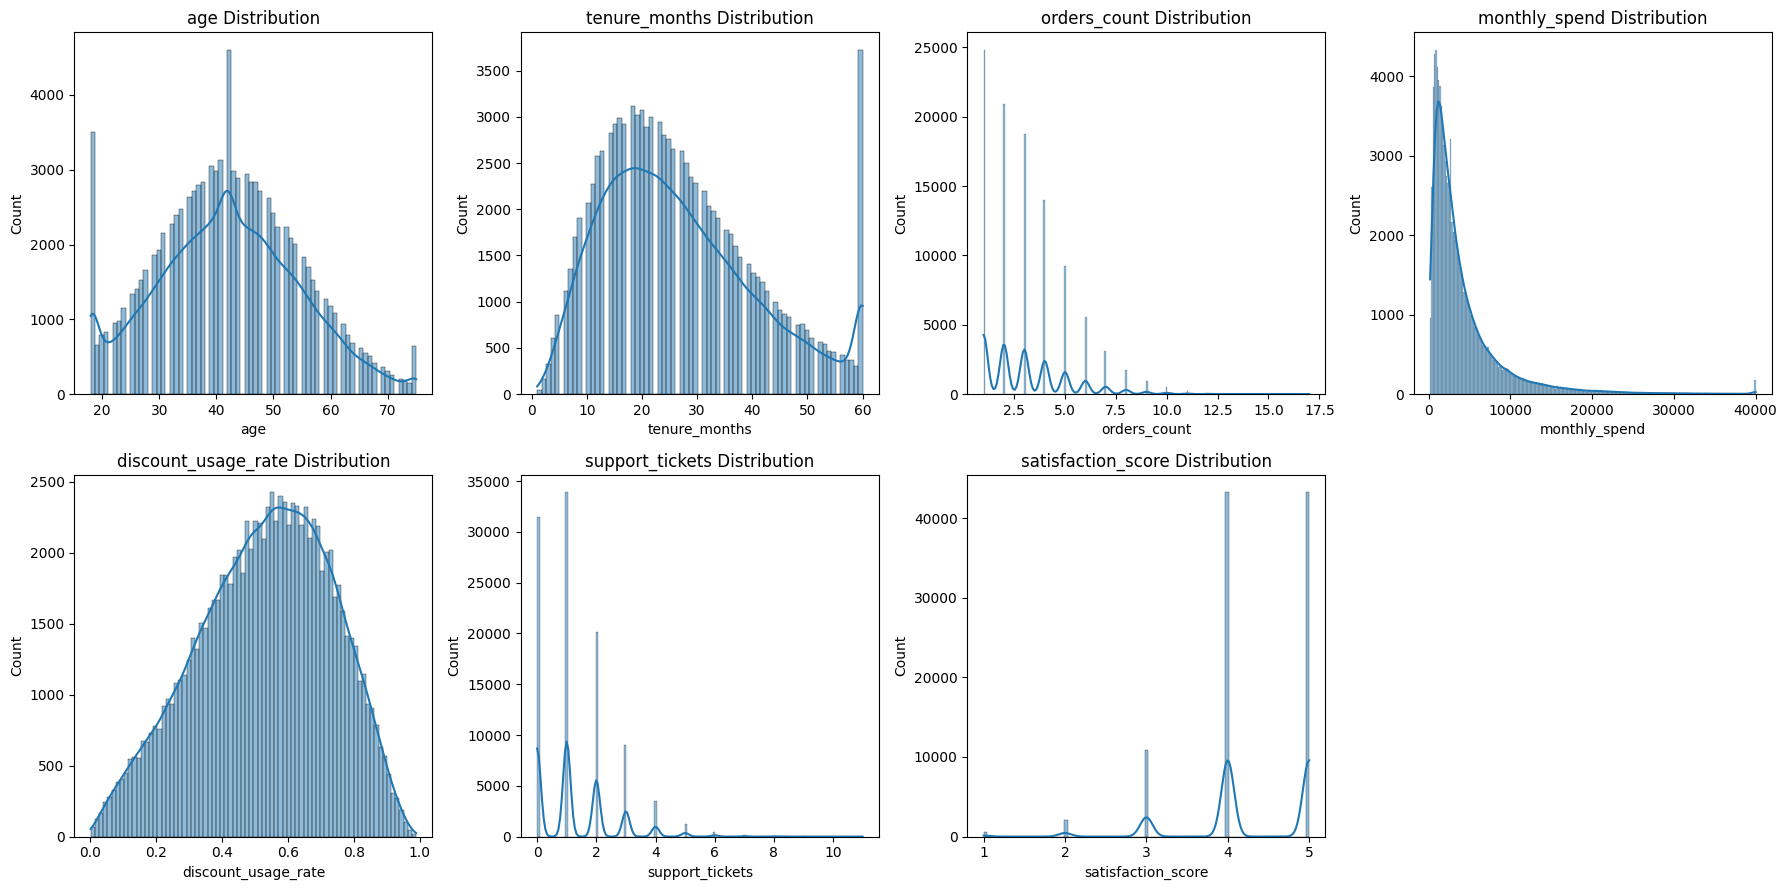

Unique cities after standardization:
['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune', 'Unknown']


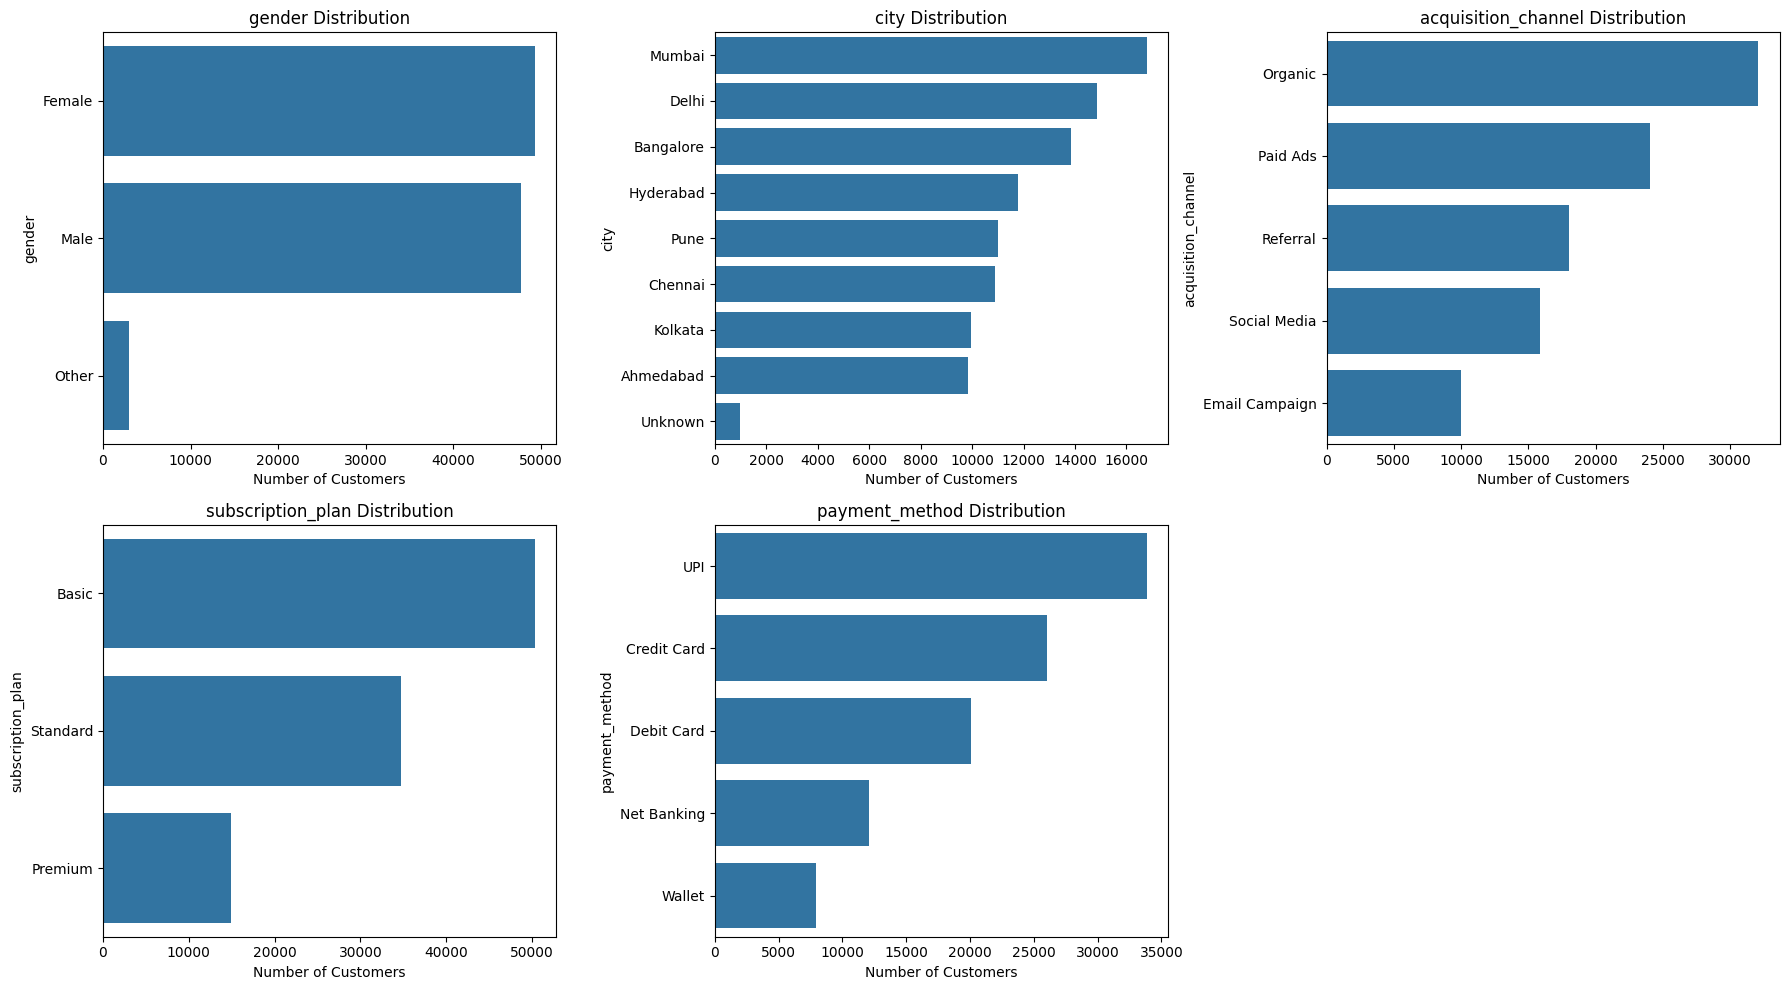

In [35]:

# EDA 1 — Customer & Churn Overview

# 1. Churn distribution
churn_counts = df["churn"].value_counts().sort_index()
churn_percent = df["churn"].value_counts(normalize=True).sort_index() * 100

print("Churn Distribution:")
display(
    pd.DataFrame({
        "count": churn_counts,
        "percentage": churn_percent.round(2)
    })
)

# 2. Numerical feature distributions
numeric_cols = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


# 3. Categorical feature distributions
categorical_cols = [
    "gender",
    "city",
    "acquisition_channel",
    "subscription_plan",
    "payment_method"
]

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize city names
df["city"] = df["city"].str.title()

# Check unique city values after standardization
print("Unique cities after standardization:")
print(sorted(df["city"].unique()))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Show top 10 categories where there are many categories
    value_counts = df[col].value_counts().head(10)

    sns.barplot(
        x=value_counts.values,
        y=value_counts.index,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Number of Customers")
    axes[i].set_ylabel(col)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Average values by churn status:


churn,Not Churned,Churned
age,42.10,42.07
tenure_months,28.65,21.87
orders_count,3.44,2.25
monthly_spend,4820.99,2623.79
discount_usage_rate,0.52,0.57
support_tickets,1.09,1.71
satisfaction_score,4.41,3.88


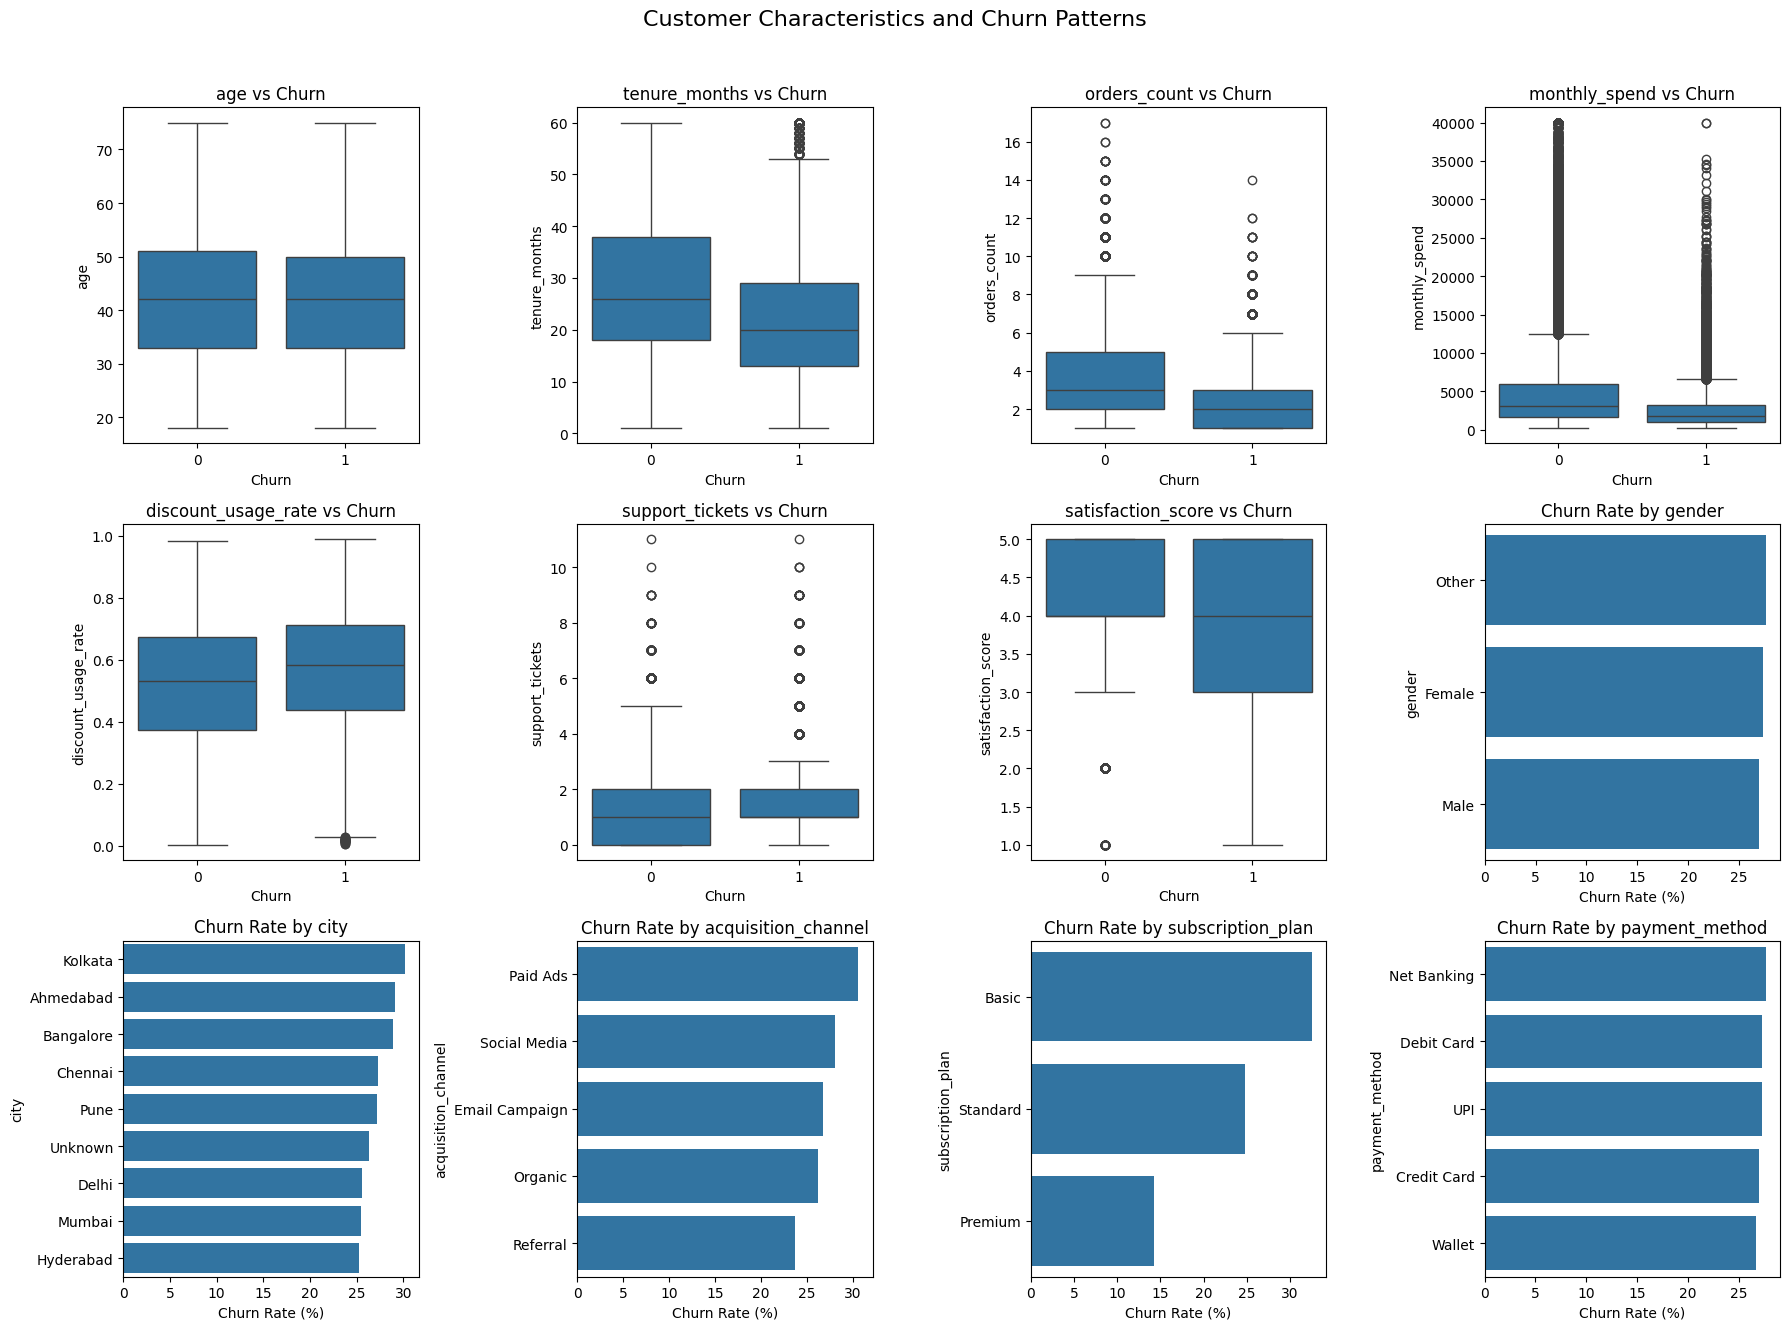

In [ ]:

# EDA 2 — Churn Pattern Dashboard

numeric_cols = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score"
]

categorical_cols = [
    "gender",
    "city",
    "acquisition_channel",
    "subscription_plan",
    "payment_method"
]


# 1. Numerical comparison
print("Average values by churn status:")

display(
    df.groupby("churn")[numeric_cols]
      .mean()
      .T
      .rename(columns={
          0: "Not Churned",
          1: "Churned"
      })
      .round(2)
)


# 2. Create one combined figure
fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 13)
)

axes = axes.flatten()


# Numerical features
for i, col in enumerate(numeric_cols):

    sns.boxplot(
        data=df,
        x="churn",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)


# Categorical features
for i, col in enumerate(categorical_cols, start=7):

    churn_rate = (
        df.groupby(col)["churn"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index()
    )

    sns.barplot(
        data=churn_rate,
        x="churn",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel("Churn Rate (%)")
    axes[i].set_ylabel(col)


plt.suptitle(
    "Customer Characteristics and Churn Patterns",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:

# Feature Engineering

# Fix logically invalid order dates
invalid_dates = df["last_order_date"] < df["signup_date"]

df.loc[invalid_dates, "last_order_date"] = df.loc[
    invalid_dates, "signup_date"
]

# Reference date for recency
reference_date = df["last_order_date"].max()

# 1. Customer recency
df["recency_days"] = (
    reference_date - df["last_order_date"]
).dt.days

# 2. Order frequency
df["orders_per_month"] = (
    df["orders_count"] / df["tenure_months"]
)

# 3. Support ticket frequency
df["support_tickets_per_month"] = (
    df["support_tickets"] / df["tenure_months"]
)

# Remove the questionable spend_per_order feature
if "spend_per_order" in df.columns:
    df.drop(columns="spend_per_order", inplace=True)

# Summary
new_features = [
    "recency_days",
    "orders_per_month",
    "support_tickets_per_month"
]

print("Invalid order dates corrected:", invalid_dates.sum())
print("Reference date:", reference_date)

display(df[new_features].describe().T)

print("\nEngineered features by churn:")
display(
    df.groupby("churn")[new_features]
      .mean()
      .T
      .rename(columns={
          0: "Not Churned",
          1: "Churned"
      })
      .round(3)
)

Invalid order dates corrected: 1013
Reference date: 2025-12-30 00:00:00


,count,mean,std,min,25%,50%,75%,max
recency_days,100000.0,107.773450,68.079904,0.000000,58.000000,95.000000,144.000000,1808.0
orders_per_month,100000.0,0.137434,0.107614,0.016667,0.071429,0.111111,0.166667,4.0
support_tickets_per_month,100000.0,0.067366,0.107467,0.000000,0.000000,0.040000,0.086957,5.0



Engineered features by churn:


churn,Not Churned,Churned
recency_days,92.924,147.597
orders_per_month,0.141,0.128
support_tickets_per_month,0.049,0.116


Correlation with churn:


,correlation
recency_days,0.357
satisfaction_score,-0.302
support_tickets_per_month,0.279
orders_count,-0.265
support_tickets,0.221
tenure_months,-0.216
monthly_spend,-0.205
discount_usage_rate,0.110
orders_per_month,-0.056
age,-0.001


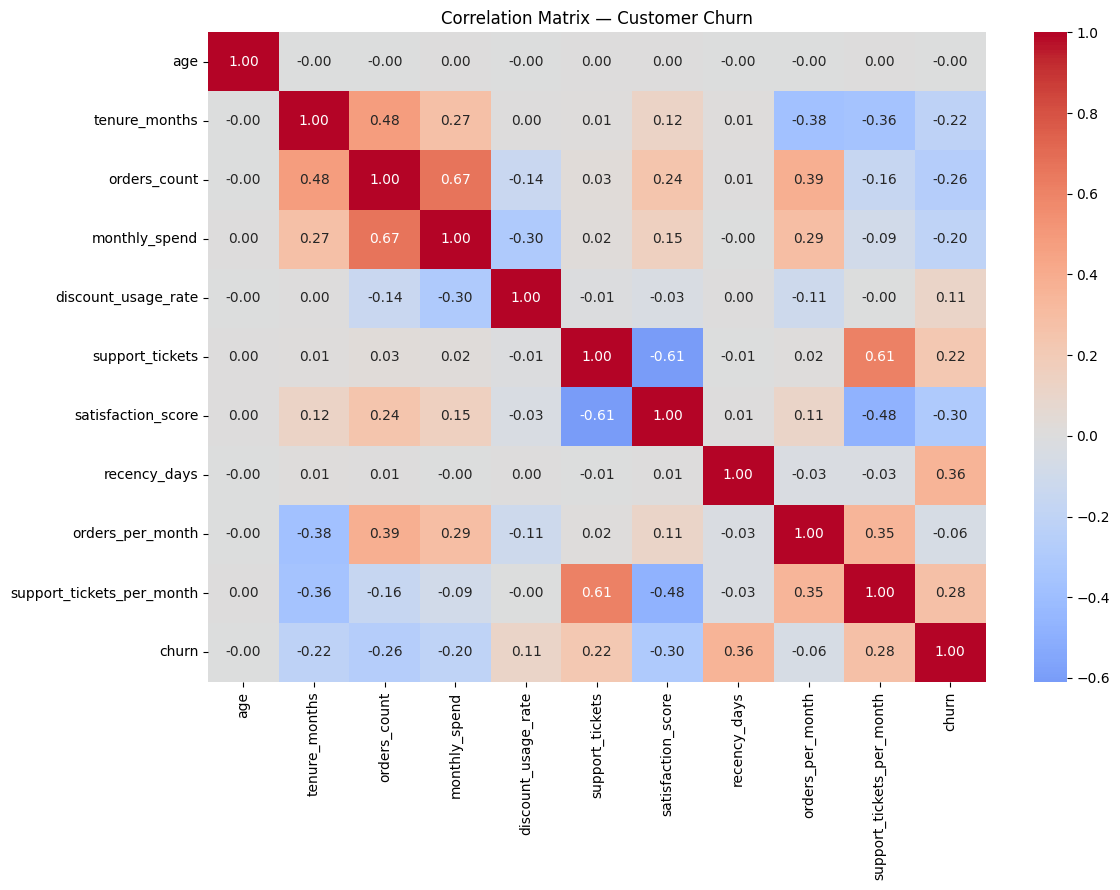

In [ ]:
# Final EDA — Correlation Analysis

# Numerical features including engineered features
analysis_cols = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score",
    "recency_days",
    "orders_per_month",
    "support_tickets_per_month",
    "churn"
]

# Correlation matrix
corr_matrix = df[analysis_cols].corr()

# Correlation with churn
churn_corr = (
    corr_matrix["churn"]
    .drop("churn")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with churn:")
display(churn_corr.to_frame("correlation").round(3))


# Correlation heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Customer Churn")
plt.tight_layout()
plt.show()

In [39]:
# -----------------------------
# Save Cleaned & Engineered Data
# -----------------------------

output_path = "../data/processed/customer_churn_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print("Path:", output_path)
print("Shape:", df.shape)

Cleaned dataset saved successfully.
Path: ../data/processed/customer_churn_cleaned.csv
Shape: (100000, 19)
